In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("PHASE 1: BANK CHURN DATA EXPLORATION")
print("="*60)

PHASE 1: BANK CHURN DATA EXPLORATION


In [4]:
# Load dataset
print("\n1. LOADING DATA...")
df = pd.read_csv('data/European_Bank.csv')
print(f"   Dataset shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")
df.head()


1. LOADING DATA...
   Dataset shape: (10000, 14)
   Columns: ['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
print("\n2. DATA INFORMATION:")
print(df.info())


2. DATA INFORMATION:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB
None


In [6]:
print("\n3. MISSING VALUES:")
print(df.isnull().sum())


3. MISSING VALUES:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [7]:
print("\n4. STATISTICAL SUMMARY:")
df.describe()


4. STATISTICAL SUMMARY:


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
print("\n5. TARGET DISTRIBUTION (Exited = Churned):")
churn_count = df['Exited'].value_counts()
churn_rate = df['Exited'].mean() * 100
print(f"   Retained (0): {churn_count[0]} customers ({100-churn_rate:.1f}%)")
print(f"   Churned (1):  {churn_count[1]} customers ({churn_rate:.1f}%)")


5. TARGET DISTRIBUTION (Exited = Churned):
   Retained (0): 7963 customers (79.6%)
   Churned (1):  2037 customers (20.4%)


In [9]:
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS...")
print("="*60)

import os
os.makedirs('figures', exist_ok=True)
print("Figures folder created!")


GENERATING VISUALIZATIONS...
Figures folder created!


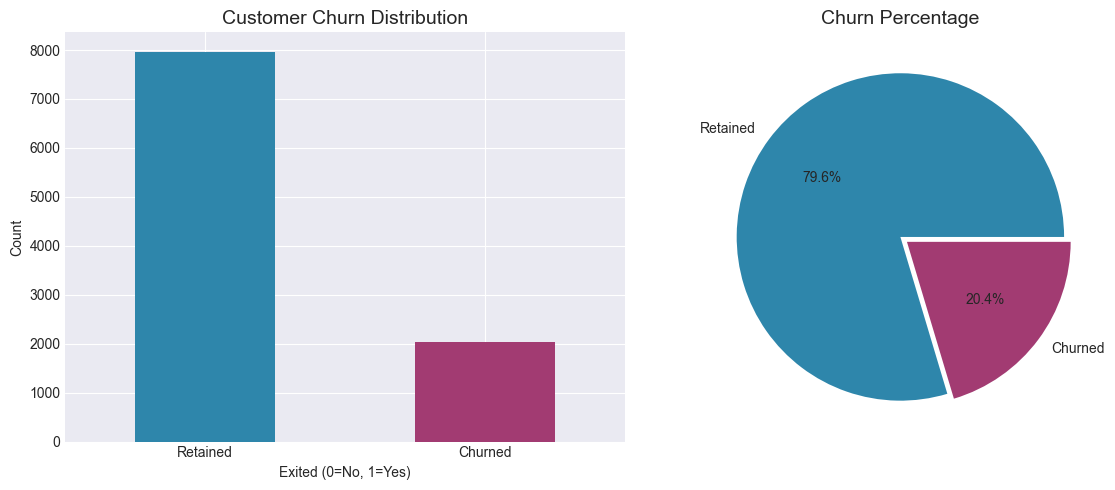

✓ Figure 1 saved: 01_churn_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2E86AB', '#A23B72']
churn_count.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Customer Churn Distribution', fontsize=14)
axes[0].set_xlabel('Exited (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Retained', 'Churned'], rotation=0)

axes[1].pie(churn_count.values, labels=['Retained', 'Churned'], autopct='%1.1f%%', 
            colors=colors, explode=(0, 0.05))
axes[1].set_title('Churn Percentage', fontsize=14)

plt.tight_layout()
plt.savefig('figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved: 01_churn_distribution.png")

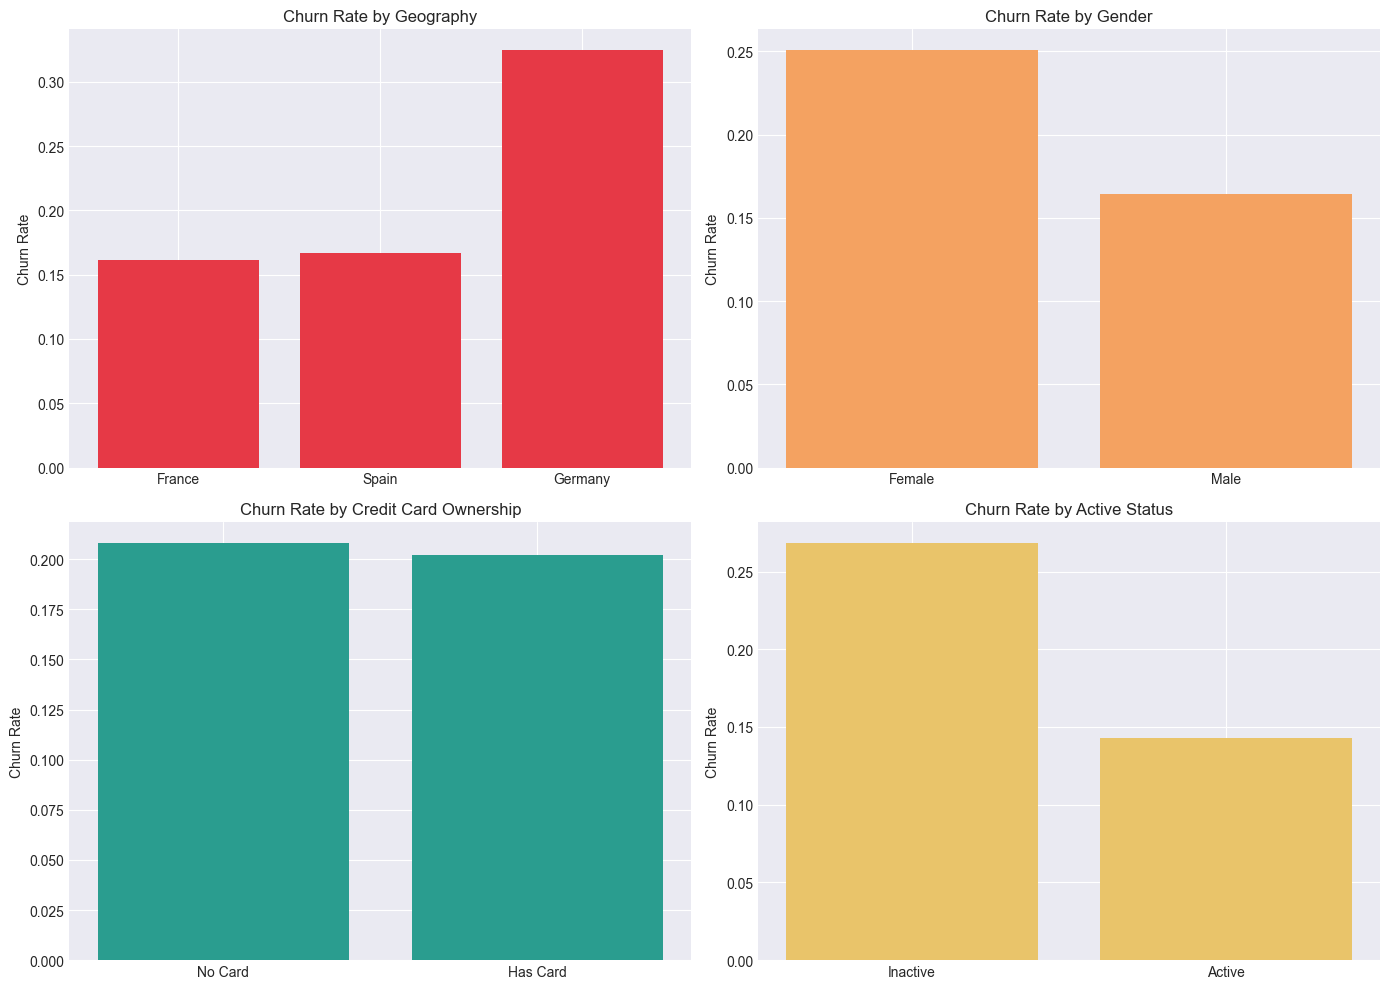

✓ Figure 2 saved: 02_feature_analysis.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Geography vs Churn
geo_churn = df.groupby('Geography')['Exited'].mean().sort_values()
axes[0,0].bar(geo_churn.index, geo_churn.values, color='#E63946')
axes[0,0].set_title('Churn Rate by Geography', fontsize=12)
axes[0,0].set_ylabel('Churn Rate')

# Gender vs Churn
gender_churn = df.groupby('Gender')['Exited'].mean()
axes[0,1].bar(gender_churn.index, gender_churn.values, color='#F4A261')
axes[0,1].set_title('Churn Rate by Gender', fontsize=12)
axes[0,1].set_ylabel('Churn Rate')

# HasCrCard vs Churn
card_churn = df.groupby('HasCrCard')['Exited'].mean()
axes[1,0].bar(['No Card', 'Has Card'], card_churn.values, color='#2A9D8F')
axes[1,0].set_title('Churn Rate by Credit Card Ownership', fontsize=12)
axes[1,0].set_ylabel('Churn Rate')

# IsActiveMember vs Churn
active_churn = df.groupby('IsActiveMember')['Exited'].mean()
axes[1,1].bar(['Inactive', 'Active'], active_churn.values, color='#E9C46A')
axes[1,1].set_title('Churn Rate by Active Status', fontsize=12)
axes[1,1].set_ylabel('Churn Rate')

plt.tight_layout()
plt.savefig('figures/02_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved: 02_feature_analysis.png")

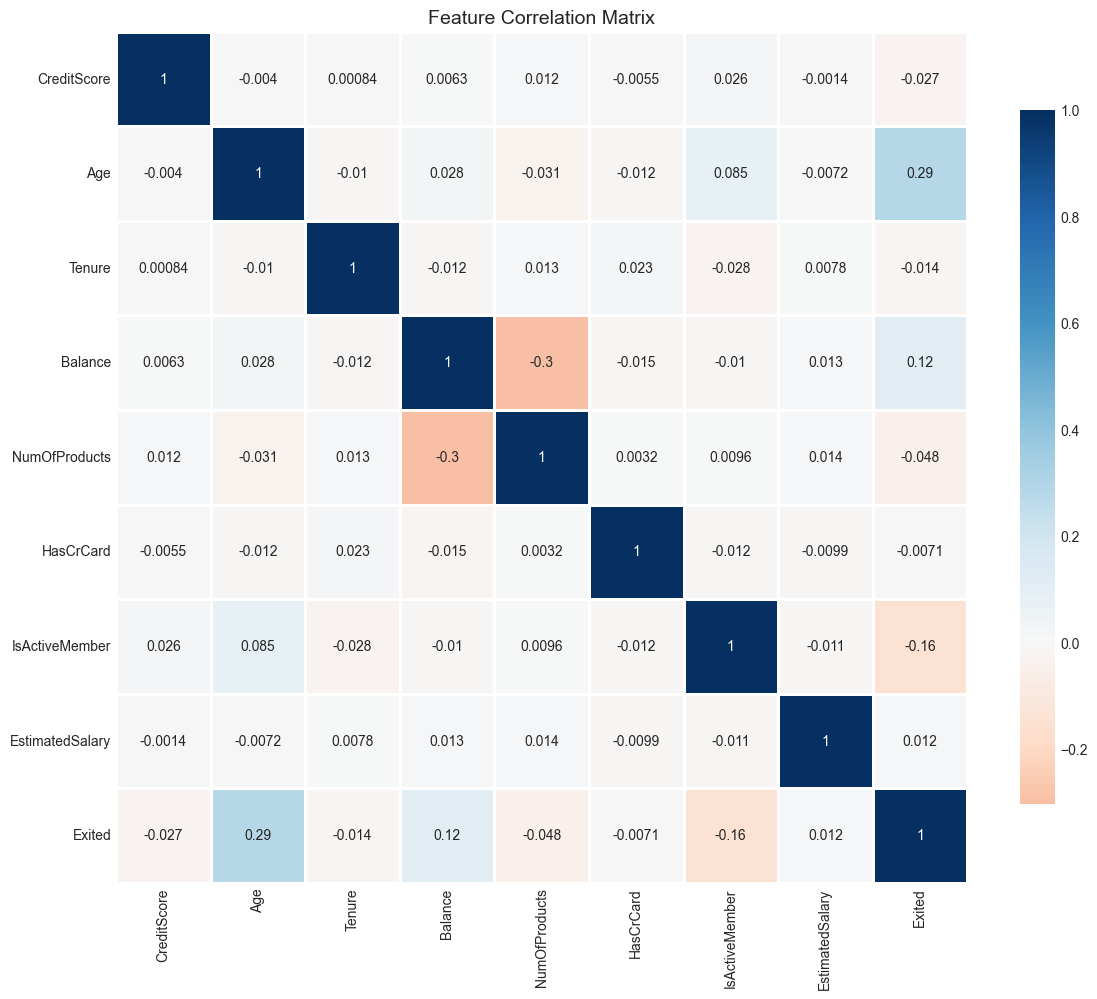

✓ Figure 3 saved: 03_correlation_heatmap.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 10))

numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.savefig('figures/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved: 03_correlation_heatmap.png")

In [13]:
print("\n" + "="*60)
print("PHASE 1 COMPLETE!")
print("="*60)
print("\n KEY INSIGHTS:")
print(f"   • Churn Rate: {churn_rate:.1f}%")
print(f"   • Germany has highest churn: {geo_churn['Germany']*100:.1f}%")
print(f"   • Women churn more: {gender_churn['Female']*100:.1f}%")
print(f"   • Inactive members have {active_churn[0]*100:.1f}% churn rate")
print(f"   • Age has strongest correlation with churn: {corr_matrix.loc['Age','Exited']:.3f}")


PHASE 1 COMPLETE!

 KEY INSIGHTS:
   • Churn Rate: 20.4%
   • Germany has highest churn: 32.4%
   • Women churn more: 25.1%
   • Inactive members have 26.9% churn rate
   • Age has strongest correlation with churn: 0.285
